# 2D clinic Hamiltonian — elastic $H$ structure

Study the **3D elastic evolution Hamiltonian** from the clinic code, focusing on matrix structure before block encoding.

**Operator** (`_utility.FD_solver_3D_elastic`):
$$
H = i\,B^{-1/2} A\,B^{-1/2}, \qquad \dot\psi = -i H \psi.
$$

**Note:** there is no separate 2D elastic builder in `_utility.py`. This notebook uses **3D elastic** on a small grid with **thin $N_z$** (a quasi-2D $xy$ slice with minimal $z$ extent). That is the same staggered $(v,\sigma)$ formulation as the full clinic.

**State ordering** (`plot_elastic_3D`):
$$
\psi = [\,v_x \mid v_y \mid v_z \mid \sigma_{xx} \mid \sigma_{yy} \mid \sigma_{zz} \mid \sigma_{xy} \mid \sigma_{xz} \mid \sigma_{yz}\,].
$$

**Related notebooks**
- Scalar Poisson oracle (different matrix $G$): [`block_encoding_laplacian_2d_two_material.ipynb`](block_encoding_laplacian_2d_two_material.ipynb)
- 1D LCU basics: [`block_encoding_laplacian_1d.ipynb`](block_encoding_laplacian_1d.ipynb)

Helper modules: `_utility.py`, `_block_encoding_hamiltonian.py`.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(os.getcwd()))
import importlib
import _block_encoding_hamiltonian as be_h
importlib.reload(be_h)
from _block_encoding_hamiltonian import (
    anti_hermitian_error,
    block_boundaries,
    clinic_elastic_materials,
    coefficient_labeling_table,
    dense_matrix,
    diagonal_material_catalog,
    elastic_3d_layout,
    hermitian_error,
    label_coefficients_by_block,
    summarize_block_coupling,
    summarize_coefficient_labeling,
)
from _block_encoding_common import spectral_scale, transpiled_gate_counts, data_loading_subcircuit
from _utility import FD_solver_3D_elastic


/Users/pavelfilippov/PycharmProjects/Quantum-Wave-Simulation-with-Sources-and-Loss-Functions/.venv/lib/python3.12/site-packages/qiskit/synthesis/discrete_basis/generate_basis_approximations.py:63: RuntimeWarning: The SolovayKitaev algorithm relies on scikit-learn's KDTree for a fast search over the basis approximations. Without this, we fallback onto a greedy search with is significantly slower. We highly suggest to install scikit-learn to use this feature.
  warnings.warn(


## 1. Build clinic elastic $H$ and verify structure

Small 3D elastic grid ($N_x=N_y=4$, $N_z=2$) with clinic rock/fracture materials. We assemble $H$, $A$, $B$ via `FD_solver_3D_elastic`, check $A^\top \approx -A$ and $H^\dagger \approx H$, and plot the sparsity pattern with velocity/stress block boundaries.

In [2]:
NX, NY, NZ = 4, 4, 2
DX = DY = DZ = 0.05
BCS = {"L": "DBC", "R": "DBC", "T": "DBC", "B": "DBC", "F": "DBC", "Ba": "DBC"}

rho_model, S, fracture_mask = clinic_elastic_materials(NX, NY, NZ, add_fractures=True)
layout = elastic_3d_layout(NX, NY, NZ)

print("DOF layout [v | sigma]:")
for name, sl in layout.slices().items():
    print(f"  {name:10s}  indices {sl.start:4d}:{sl.stop:4d}  (size {sl.stop - sl.start})")
print(f"\nVelocity DOFs: {layout.n_vel}   Stress DOFs: {layout.n_stress}   Total N = {layout.n_total}")
print(f"Fracture cells: {fracture_mask.sum()} / {fracture_mask.size}")

H, A, B, B_sqrt, B_inv, B_inv_sqrt = FD_solver_3D_elastic(
    NX, NY, NZ, DX, DY, DZ, rho_model, S, BCS
)

print(f"\n|A + A^T|_max = {anti_hermitian_error(A):.2e}")
print(f"|H - H^dagger|_max = {hermitian_error(H):.2e}")
print(f"||H||_2 = {np.linalg.norm(dense_matrix(H), 2):.4g}")

DOF layout [v | sigma]:
  v_x         indices    0:  24  (size 24)
  v_y         indices   24:  48  (size 24)
  v_z         indices   48:  64  (size 16)
  sigma_xx    indices   64:  96  (size 32)
  sigma_yy    indices   96: 128  (size 32)
  sigma_zz    indices  128: 160  (size 32)
  sigma_xy    indices  160: 178  (size 18)
  sigma_xz    indices  178: 190  (size 12)
  sigma_yz    indices  190: 202  (size 12)

Velocity DOFs: 64   Stress DOFs: 138   Total N = 202
Fracture cells: 20 / 32

|A + A^T|_max = 0.00e+00
|H - H^dagger|_max = 2.91e-11
||H||_2 = 2.485e+05


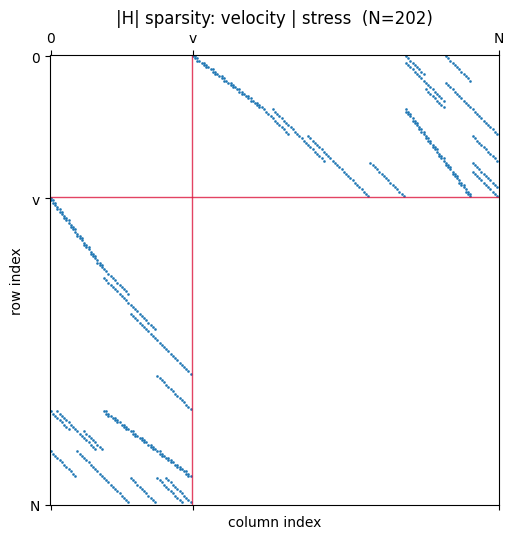

In [3]:
H_dense = dense_matrix(H)
ticks = block_boundaries(layout, coarse=True)
tick_labels = ["0", "v", "N"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.spy(np.abs(H_dense) > 0, markersize=0.8, color="C0")
for t in ticks[1:-1]:
    ax.axhline(t - 0.5, color="crimson", lw=1.0, alpha=0.8)
    ax.axvline(t - 0.5, color="crimson", lw=1.0, alpha=0.8)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)
ax.set_xlabel("column index")
ax.set_ylabel("row index")
ax.set_title(f"|H| sparsity: velocity | stress  (N={layout.n_total})")
plt.tight_layout()
plt.show()

## 2. Block annotation: velocity–stress structure of $H$

The first-order elastic system matrix has the block layout (`compute_A_elastic_3D`)
$$
A = \begin{pmatrix} 0 & D \\ -D^\top & 0 \end{pmatrix},
$$
on $[v_x, v_y, v_z \mid \sigma_{xx}, \ldots, \sigma_{yz}]$, with $D$ the staggered divergence linking stress to velocity.

$B^{-1/2}$ is **block-diagonal** in the same ordering: density on velocity blocks, compliance on stress blocks. Fractures change local $B$ entries (and hence $H$) without changing the global block template.

Below: coarse velocity$\leftrightarrow$stress coupling, fine block table for $A$, and a zoom on one $D$ tile ($v_x \leftarrow \sigma_{xx}$).

In [4]:
def coupling_table(matrix, block_slices, label):
    rows = []
    for (row_name, col_name), (nnz, peak) in summarize_block_coupling(
        dense_matrix(matrix), block_slices
    ).items():
        rows.append({
            "matrix": label,
            "row_block": row_name,
            "col_block": col_name,
            "nnz": nnz,
            "max_abs": peak,
        })
    return pd.DataFrame(rows)

coarse = layout.coarse_slices()
df_coarse = coupling_table(H, coarse, "H")
display(df_coarse.pivot_table(
    index="row_block", columns="col_block", values="nnz", fill_value=0
))

df_fine = coupling_table(A, layout.slices(), "A")
pivot = df_fine.pivot_table(
    index="row_block", columns="col_block", values="nnz", fill_value=0
)
print("Nonzero counts in A (fine blocks):")
display(pivot.loc[["v_x", "v_y", "v_z"], [c for c in pivot.columns if c.startswith("sigma")]])

col_block,stress,velocity
row_block,,
stress,0.0,296.0
velocity,296.0,0.0


Nonzero counts in A (fine blocks):


col_block,sigma_xx,sigma_xy,sigma_xz,sigma_yy,sigma_yz,sigma_zz
row_block,,,,,,
v_x,48.0,36.0,24.0,0.0,0.0,0.0
v_y,0.0,36.0,0.0,48.0,24.0,0.0
v_z,0.0,0.0,24.0,0.0,24.0,32.0


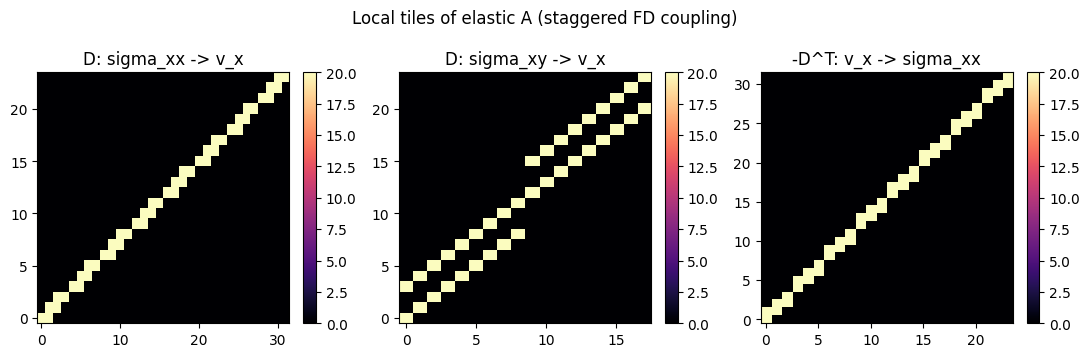

Takeaway: H is block-sparse with velocity-stress coupling; not a scalar 5-point Laplacian.


In [5]:
A_dense = dense_matrix(A)
vx_sl, sxx_sl = layout.vx_slice, layout.sxx_slice

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
panels = [
    ("D: sigma_xx -> v_x", A_dense[vx_sl, sxx_sl]),
    ("D: sigma_xy -> v_x", A_dense[vx_sl, layout.sxy_slice]),
    ("-D^T: v_x -> sigma_xx", A_dense[sxx_sl, vx_sl]),
]
for ax, (title, block) in zip(axes, panels):
    im = ax.imshow(np.abs(block), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Local tiles of elastic A (staggered FD coupling)")
plt.tight_layout()
plt.show()

print("Takeaway: H is block-sparse with velocity-stress coupling; not a scalar 5-point Laplacian.")

In [6]:
# Homogeneous vs fractured H: which block tiles change?
rho_homo, S_homo, _ = clinic_elastic_materials(NX, NY, NZ, add_fractures=False)
H_homo, *_ = FD_solver_3D_elastic(NX, NY, NZ, DX, DY, DZ, rho_homo, S_homo, BCS)

base = summarize_block_coupling(dense_matrix(H_homo), coarse)
frac = summarize_block_coupling(dense_matrix(H), coarse)
changed = [
    key for key in base
    if base[key][0] != frac[key][0]
    or not np.isclose(base[key][1], frac[key][1])
]
print(f"Coarse tiles changed by fractures: {changed}")


Coarse tiles changed by fractures: [('velocity', 'stress'), ('stress', 'velocity')]


## 3. Label distinct coefficients per block (oracle design)

Pechan-style relabeling for $H$: each nonzero entry belongs to a **block section**
$(\text{row\_block}, \text{col\_block})$.  Distinct values within a section get
$d_{\mathrm{val}}$; the section index is $d_{\mathrm{ind}}$, so
$$
d = d_{\mathrm{ind}}\,\|\, d_{\mathrm{val}}.
$$
The same magnitude in different sections receives **different** $d$ labels (needed for $O_{\mathrm{data}}$).

We also catalog diagonal **material** coefficients in $B^{-1/2}$ per block — the natural split before encoding $iA$ and $B^{-1/2}$ separately.

In [7]:
labeling_H = label_coefficients_by_block(H, layout, matrix_name="H")
summary_H = summarize_coefficient_labeling(labeling_H)

print(f"H: D' = {summary_H['D_prime']} distinct labels  (D_padded = {summary_H['D_padded']})")
print(f"    sections = {summary_H['n_sections']},  d_ind bits = {summary_H['d_ind_bits']},  d_val bits = {summary_H['d_val_bits']}")
print(f"    n_d qubits ~ {summary_H['n_d_qubits']}")

display(coefficient_labeling_table(labeling_H))

H: D' = 96 distinct labels  (D_padded = 256)
    sections = 18,  d_ind bits = 5,  d_val bits = 3
    n_d qubits ~ 8


,section,n_distinct,matrix
0,sigma_xx -> v_x,8,H
1,sigma_xy -> v_x,6,H
2,sigma_xy -> v_y,8,H
3,sigma_xz -> v_x,4,H
4,sigma_xz -> v_z,6,H
5,sigma_yy -> v_y,4,H
6,sigma_yz -> v_y,4,H
7,sigma_yz -> v_z,4,H
8,sigma_zz -> v_z,4,H
9,v_x -> sigma_xx,8,H


In [8]:
# Coupling sections (velocity <-> stress) carry fracture-induced coefficient variety
coupling_sections = [
    row for row in summary_H["distinct_values_per_section"]
    if ("v_" in row.split(" -> ")[0] and "sigma" in row.split(" -> ")[1])
    or ("sigma" in row.split(" -> ")[0] and "v_" in row.split(" -> ")[1])
]
rows = []
for section in coupling_sections:
    vals = summary_H["section_values"][section]
    rows.append({
        "section": section,
        "n_distinct": len(vals),
        "sample": [f"{v.real:.4g}" for v in vals[:4]],
    })
display(pd.DataFrame(rows))

material_df = diagonal_material_catalog(B_inv_sqrt, layout)
print("\nDiagonal B^{-1/2} material catalog (per block):")
display(material_df[["block", "n_dof", "n_distinct"]])

,section,n_distinct,sample
0,sigma_xx -> v_x,8,"[0, 0, 0, 0]"
1,sigma_xy -> v_x,6,"[0, 0, 0, 0]"
2,sigma_xy -> v_y,8,"[0, 0, 0, 0]"
3,sigma_xz -> v_x,4,"[0, 0, 0, 0]"
4,sigma_xz -> v_z,6,"[0, 0, 0, 0]"
5,sigma_yy -> v_y,4,"[0, 0, 0, 0]"
6,sigma_yz -> v_y,4,"[0, 0, 0, 0]"
7,sigma_yz -> v_z,4,"[0, 0, 0, 0]"
8,sigma_zz -> v_z,4,"[0, 0, 0, 0]"
9,v_x -> sigma_xx,8,"[0, 0, 0, 0]"



Diagonal B^{-1/2} material catalog (per block):


,block,n_dof,n_distinct
0,v_x,24,3
1,v_y,24,2
2,v_z,16,2
3,sigma_xx,32,2
4,sigma_yy,32,2
5,sigma_zz,32,2
6,sigma_xy,18,3
7,sigma_xz,12,2
8,sigma_yz,12,2


In [9]:
# Homogeneous vs fractured: how label count scales
labeling_homo = label_coefficients_by_block(H_homo, layout, matrix_name="H_homo")

rows = []
for name, labeling in [("fractured", labeling_H), ("homogeneous", labeling_homo)]:
    s = summarize_coefficient_labeling(labeling)
    rows.append({
        "case": name,
        "D_prime": s["D_prime"],
        "n_sections": s["n_sections"],
        "max_distinct_in_section": max(s["distinct_values_per_section"].values()),
    })
display(pd.DataFrame(rows))

# O_data T-gate budget at spectral scale (real part load for block-encoding prototype)
alpha_H = spectral_scale(dense_matrix(H))
value_table_real = np.real(labeling_H.value_table)
odata = data_loading_subcircuit(value_table_real, alpha_H)
odata_counts = transpiled_gate_counts(odata)
print(f"\nO_data prototype (|Re(value_table)|, alpha=||H||_2): T-gates = {odata_counts['t_gates']}")

,case,D_prime,n_sections,max_distinct_in_section
0,fractured,96,18,8
1,homogeneous,36,18,2



O_data prototype (|Re(value_table)|, alpha=||H||_2): T-gates = 30668
